Worked on by: Thomas Van Sande

This notebook contains the code that was created on the AWS Sagemaker notebook environment. In AWS we created a forecasting model for the demand dataset.

In [30]:
!pip install --upgrade sagemaker pandas boto3 numpy matplotlib --quiet

import os
import json
import boto3
import sagemaker
import pandas as pd
import numpy as np
from datetime import datetime
from sagemaker import image_uris
from sagemaker.estimator import Estimator
from sagemaker.session import Session

sess = sagemaker.Session()
region = sess.boto_region_name

try:
    role = sagemaker.get_execution_role()
except Exception:
    role = "arn:aws:iam::315301634495:role/service-role/AmazonSageMaker-ExecutionRole-20251120T161895"

print(f"Region: {region}")
print(f"Role: {role}")


Region: eu-north-1
Role: arn:aws:iam::315301634495:role/service-role/AmazonSageMaker-ExecutionRole-20251120T161895


In [31]:
csv_path = "cleaned_data.csv"
df = pd.read_csv(csv_path)
print(f"Rows in original data: {len(df)}")
df.head(5)

Rows in original data: 346328


,settlement_period,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,britned_flow,moyle_flow,year,month,day
0,1,38596,39660.0,34982,0.0,0.0,0.0,0.0,0,295,1997,0.0,-169.0,2006,1,1
1,2,38829,39897.0,35312,0.0,0.0,0.0,0.0,0,299,1997,0.0,-169.0,2006,1,1
2,3,38456,39599.0,35018,0.0,0.0,0.0,0.0,0,374,1998,0.0,-169.0,2006,1,1
3,4,37401,38823.0,34054,0.0,0.0,0.0,0.0,0,653,1998,0.0,-169.0,2006,1,1
4,5,36586,37937.0,33297,0.0,0.0,0.0,0.0,0,582,1998,0.0,-169.0,2006,1,1


AWS uses DeepAR for its forecasting and we need to convert the dates to the right format so DeepAR can handle it. We also are gonna group it daily since monthly will not work. DeepAR needs more than 300 entries and if we group it by month as we did in notebook 3 it can't build it. We'll then just use the next 180 days to have a similar time window.

In [32]:

df["timestamp"] = (
    pd.to_datetime(df[["year", "month", "day"]]) +
    pd.to_timedelta((df["settlement_period"] - 1) * 30, unit="min")
)

daily_df = df.resample("D", on="timestamp").mean().reset_index().rename(columns={"timestamp": "date"})

for col in ["settlement_period", "day", "year", "month"]:
    if col in daily_df.columns:
        daily_df = daily_df.drop(columns=[col])

print(f"Rows after daily aggregation: {len(daily_df)}")
daily_df.head(5)



Rows after daily aggregation: 7216


,date,nd,tsd,england_wales_demand,embedded_wind_generation,embedded_wind_capacity,embedded_solar_generation,embedded_solar_capacity,non_bm_stor,pump_storage_pumping,ifa_flow,britned_flow,moyle_flow
0,2006-01-01,36991.250000,38241.187500,33282.895833,0.0,0.0,0.0,0.0,0.000000,471.937500,1872.875000,0.0,-178.000000
1,2006-01-02,39127.937500,40219.500000,35326.437500,0.0,0.0,0.0,0.0,4.458333,395.750000,1372.916667,0.0,-100.270833
2,2006-01-03,44824.875000,46050.645833,40935.604167,0.0,0.0,0.0,0.0,10.041667,504.895833,1783.250000,0.0,-130.916667
3,2006-01-04,46890.583333,48208.750000,42531.458333,0.0,0.0,0.0,0.0,4.687500,558.541667,1812.000000,0.0,-159.854167
4,2006-01-05,47961.104167,49330.708333,43589.354167,0.0,0.0,0.0,0.0,0.083333,551.229167,1148.937500,0.0,-177.770833


In [46]:
target_col = "england_wales_demand"
prediction_length = 180
train_df = daily_df.iloc[:-prediction_length]
test_df = daily_df.iloc[-prediction_length:]

def make_jsonl(df_subset):
    start = df_subset["date"].iloc[0].strftime("%Y-%m-%d")
    target = df_subset[target_col].tolist()
    return json.dumps({"start": start, "target": target})

with open("deepar_train.jsonl", "w") as f:
    f.write(make_jsonl(train_df) + "\n")

with open("deepar_test.jsonl", "w") as f:
    f.write(make_jsonl(test_df) + "\n")

print("Wrote train and test JSONL files.")


Wrote train and test JSONL files.


In [47]:
bucket = sess.default_bucket()
prefix = "deepar-daily-example" 

train_s3 = sess.upload_data("deepar_train.jsonl", bucket=bucket, key_prefix=f"{prefix}/train")
test_s3 = sess.upload_data("deepar_test.jsonl", bucket=bucket, key_prefix=f"{prefix}/test")

print(f"Train file uploaded to: {train_s3}")
print(f"Test file uploaded to: {test_s3}")


Train file uploaded to: s3://sagemaker-eu-north-1-315301634495/deepar-daily-example/train/deepar_train.jsonl
Test file uploaded to: s3://sagemaker-eu-north-1-315301634495/deepar-daily-example/test/deepar_test.jsonl


In [48]:
image_uri = image_uris.retrieve("forecasting-deepar", region=region)

hyperparameters = {
    "time_freq": "D",           
    "context_length": "365",     
    "prediction_length": prediction_length,   
    "epochs": "30",
    "learning_rate": "1e-3",
    "early_stopping_patience": "10",
    "num_layers": "2",
    "num_cells": "40",
    "mini_batch_size": "64",
    "likelihood": "student-t",
}

instance_type = "ml.c5.xlarge"
instance_count = 1

estimator = Estimator(
    image_uri=image_uri,
    role=role,
    instance_count=instance_count,
    instance_type=instance_type,
    output_path=f"s3://{bucket}/{prefix}/output",
    sagemaker_session=sess,
    hyperparameters=hyperparameters,
)

print("Estimator configured")


INFO:sagemaker.image_uris:Same images used for training and inference. Defaulting to image scope: inference.
INFO:sagemaker.image_uris:Ignoring unnecessary instance type: None.


Estimator configured


In [49]:
print("Starting training...")
estimator.fit({"train": train_s3, "test": test_s3}, wait=True)

INFO:sagemaker.telemetry.telemetry_logging:SageMaker Python SDK will collect telemetry to help us better understand our user's needs, diagnose issues, and deliver additional features.
To opt out of telemetry, please disable via TelemetryOptOut parameter in SDK defaults config. For more information, refer to https://sagemaker.readthedocs.io/en/stable/overview.html#configuring-and-using-defaults-with-the-sagemaker-python-sdk.
INFO:sagemaker:Creating training-job with name: forecasting-deepar-2025-11-20-17-16-15-351


Starting training...
2025-11-20 17:16:19 Starting - Starting the training job...
2025-11-20 17:16:33 Starting - Preparing the instances for training...
2025-11-20 17:17:14 Downloading - Downloading the training image............
2025-11-20 17:19:10 Training - Training image download completed. Training in progress..Docker entrypoint called with argument(s): train
Running default environment configuration script
Running custom environment configuration script
/opt/amazon/lib/python3.9/site-packages/mxnet/model.py:97: SyntaxWarning: "is" with a literal. Did you mean "=="?
  if num_device is 1 and 'dist' not in kvstore:
[11/20/2025 17:19:16 INFO 140014742558528] Reading default configuration from /opt/amazon/lib/python3.9/site-packages/algorithm/resources/default-input.json: {'_kvstore': 'auto', '_num_gpus': 'auto', '_num_kv_servers': 'auto', '_tuning_objective_metric': '', 'cardinality': 'auto', 'dropout_rate': '0.10', 'early_stopping_patience': '', 'embedding_dimension': '10', 'learning

In [50]:
print("Deploying endpoint...")
predictor = estimator.deploy(
    initial_instance_count=1,
    instance_type="ml.m5.xlarge"
)

INFO:sagemaker:Creating model with name: forecasting-deepar-2025-11-20-17-28-12-867


Deploying endpoint...


INFO:sagemaker:Creating endpoint-config with name forecasting-deepar-2025-11-20-17-28-12-867
INFO:sagemaker:Creating endpoint with name forecasting-deepar-2025-11-20-17-28-12-867


-------!

In [51]:
import boto3
sm = boto3.client('sagemaker')
response = sm.describe_endpoint(EndpointName='forecasting-deepar-2025-11-20-17-28-12-867')
print(response['EndpointStatus'])

InService


In [40]:
daily_df.to_csv("cleaned_datav2.csv")

In [52]:
payload = {
    "instances": [
        {
            "start": train_df["date"].iloc[0].strftime("%Y-%m-%d"),
            "target": train_df[target_col].tolist()
        }
    ]
}

In [53]:
runtime = boto3.client('sagemaker-runtime')
response = runtime.invoke_endpoint(
    EndpointName=predictor.endpoint_name,
    ContentType='application/json',
    Body=json.dumps(payload)
)

result = json.loads(response['Body'].read().decode())
print(result)


{'predictions': [{'mean': [22610.685546875, 23267.998046875, 23324.810546875, 23198.099609375, 21963.962890625, 19990.0546875, 19099.337890625, 22348.9296875, 22771.759765625, 23126.197265625, 22883.462890625, 22119.939453125, 20091.455078125, 19281.03515625, 23019.306640625, 23147.720703125, 23506.0, 23612.73828125, 22719.17578125, 20794.650390625, 19655.703125, 22477.9765625, 22999.943359375, 22932.2578125, 23040.994140625, 21874.65234375, 19778.140625, 18291.86328125, 21719.744140625, 21787.630859375, 21921.767578125, 21710.431640625, 20880.69140625, 19021.404296875, 17990.07421875, 21216.330078125, 21636.3828125, 21910.412109375, 21678.037109375, 20927.212890625, 18752.166015625, 17738.396484375, 21101.220703125, 21397.087890625, 21592.1953125, 21457.33984375, 20206.1640625, 18224.837890625, 16927.66796875, 20209.10546875, 20497.568359375, 20949.458984375, 20109.517578125, 19531.1328125, 17528.0703125, 16422.41796875, 20097.3125, 20505.912109375, 20563.7265625, 20080.912109375, 194

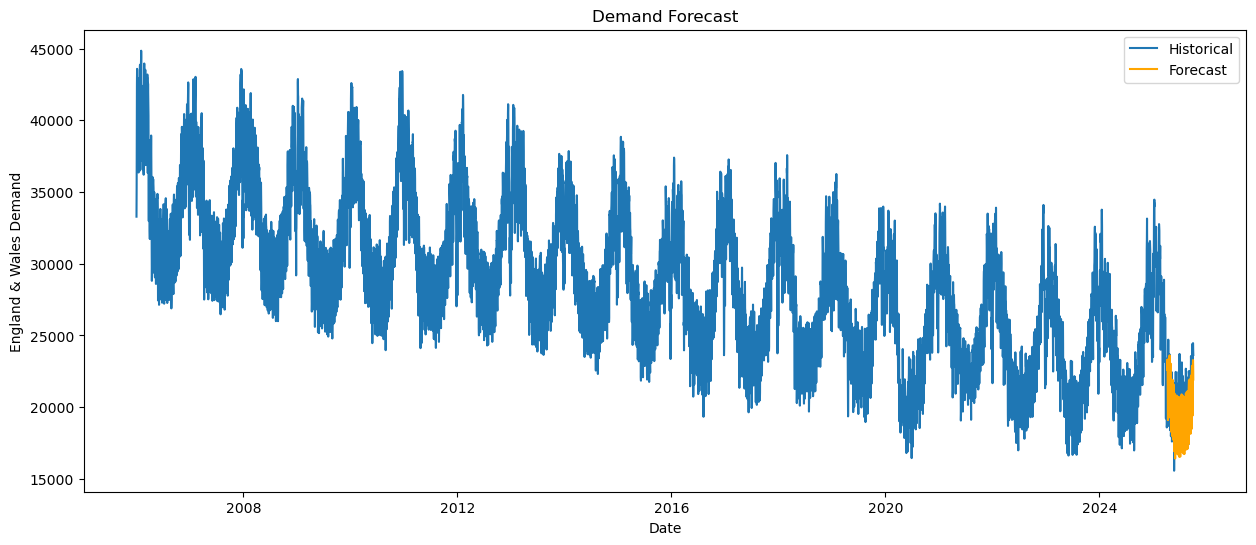

In [54]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

pred_mean = result['predictions'][0]['mean']
quantiles = result['predictions'][0].get('quantiles', {})

# Forecast dates start right after the last training date
last_train_date = train_df["date"].iloc[-1]
forecast_dates = pd.date_range(start=last_train_date + pd.Timedelta(days=1), periods=prediction_length, freq='D')

# Plot
plt.figure(figsize=(15,6))
plt.plot(daily_df["date"], daily_df[target_col], label="Historical")
plt.plot(forecast_dates, pred_mean, label="Forecast", color="orange")
if quantiles:
    lower = quantiles.get('0.1')
    upper = quantiles.get('0.9')
    if lower and upper:
        plt.fill_between(forecast_dates, lower, upper, color='orange', alpha=0.3, label='80% Prediction Interval')
plt.xlabel("Date")
plt.ylabel("England & Wales Demand")
plt.title("Demand Forecast")
plt.legend()
plt.show()


In [55]:
actual = test_df[target_col].values
predicted = np.array(pred_mean)

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)
mape = np.mean(np.abs((actual - predicted) / actual)) * 100

print(f"RMSE: {rmse:.2f}")
print(f"MAE: {mae:.2f}")
print(f"MAPE: {mape:.2f}%")


RMSE: 1234.83
MAE: 976.92
MAPE: 4.75%


This model performs worse than the one we build locally. You can see it on the graph as well as in the metrics. A RMSE of 1234 is a lot higher than the 93 we had for the monthly predictions using auto arima.